# Классификация пород кошек и собак по лицу

Используем упрощенный датасет [Oxford-IIIT Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) с вырезанными лицами домашних животных. Для начала загружаем датасет:

In [1]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2026-05-11 14:00:03--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   112KB/s    in 3m 47s  

2026-05-11 14:03:52 (105 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



### Функция для отображения изображений

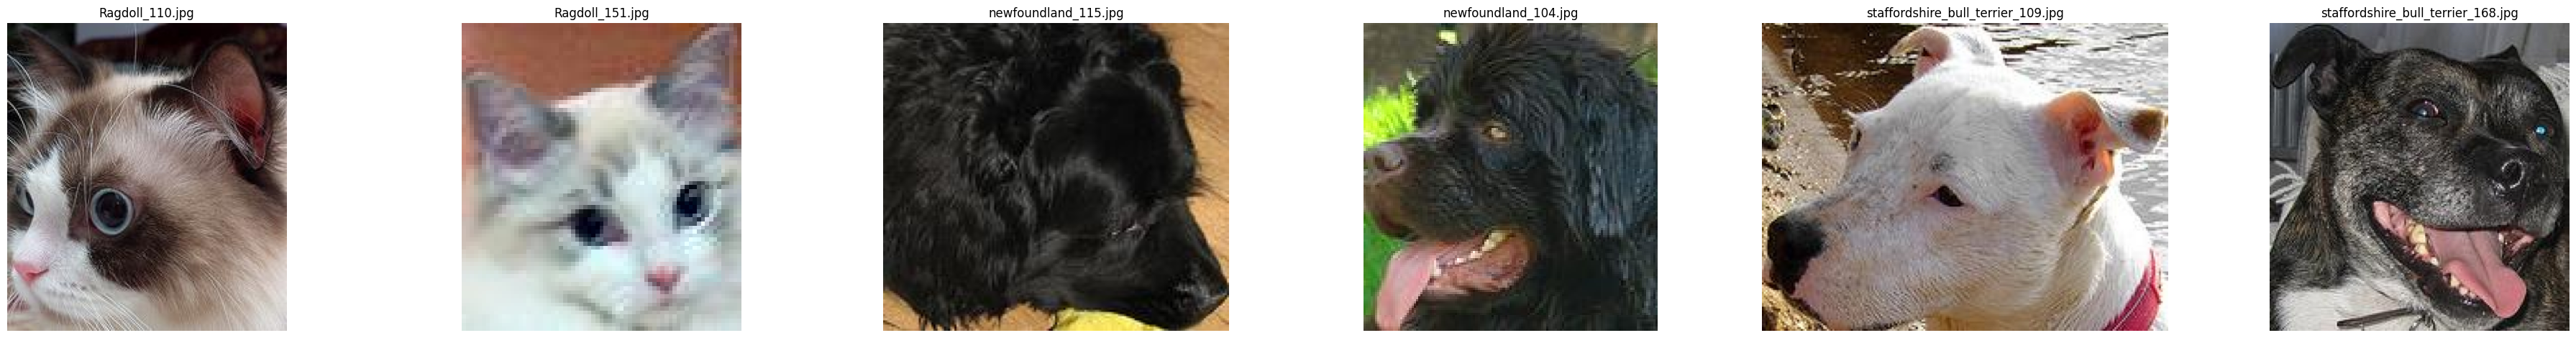

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(images, titles=None, fontsize=12):
    n = len(images)
    fig, ax = plt.subplots(1, n)
    for i, im in enumerate(images):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i], fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()[0]*n, fig.get_size_inches()[1])
    plt.tight_layout()
    plt.show()

# Проверка: покажем несколько первых изображений
sample_dir = "petfaces"
breeds = [d for d in os.listdir(sample_dir) if os.path.isdir(os.path.join(sample_dir, d))]
sample_paths = []
for breed in breeds[:3]:
    breed_dir = os.path.join(sample_dir, breed)
    imgs = os.listdir(breed_dir)[:2]
    for img in imgs:
        sample_paths.append(os.path.join(breed_dir, img))
sample_imgs = [Image.open(p) for p in sample_paths]
display_images(sample_imgs, titles=[os.path.basename(p) for p in sample_paths])

### Импорт библиотек и проверка GPU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Используется устройство: cpu


### Создание датасета с метками (порода и тип животного)

In [ ]:
data_dir = "petfaces"
class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
breed_to_idx = {breed: i for i, breed in enumerate(class_names)}

# Определяем тип: Cat или Dog по первым трём символам (в нижнем регистре)
breed_to_type = {}
for breed in class_names:
    if breed.lower().startswith("cat"):
        breed_to_type[breed] = 0   # 0 = кошка
    elif breed.lower().startswith("dog"):
        breed_to_type[breed] = 1   # 1 = собака

class PetFacesDataset(Dataset):
    def __init__(self, data_dir, breed_to_idx, breed_to_type, transform=None):
        self.samples = []
        for breed, breed_idx in breed_to_idx.items():
            breed_dir = os.path.join(data_dir, breed)
            for fname in os.listdir(breed_dir):
                if fname.lower().endswith(('.png','.jpg','.jpeg')):
                    path = os.path.join(breed_dir, fname)
                    animal_type = breed_to_type[breed]  # теперь ключ точно существует
                    self.samples.append((path, breed_idx, animal_type))
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, breed_label, animal_label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, breed_label, animal_label

# Трансформации: для обучения с аугментацией, для валидации без
transform_train = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
transform_val = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

full_dataset = PetFacesDataset(data_dir, breed_to_idx, breed_to_type, transform=transform_train)

# Стратифицированное разбиение по породам
breed_labels = [s[1] for s in full_dataset.samples]
train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, stratify=breed_labels, random_state=42)
train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
val_dataset = torch.utils.data.Subset(full_dataset, val_idx)
# Для валидации используем transform_val
val_dataset.dataset.transform = transform_val

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
print(f"Количество пород: {len(class_names)}")
print(f"Примеры пород: {class_names[:5]}")

Train samples: 2568, Val samples: 643
Количество пород: 35
Примеры пород: ['cat_Abyssinian', 'cat_Bengal', 'cat_Birman', 'cat_Bombay', 'cat_British']


### Архитектура CNN

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_breeds=36, num_types=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4))
        )
        self.fc_breed = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_breeds)
        )
        self.fc_type = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_types)
        )

    def forward(self, x):
        x = self.features(x)
        breed_out = self.fc_breed(x)
        type_out = self.fc_type(x)
        return breed_out, type_out

model = CustomCNN(num_breeds=len(class_names)).to(device)
print(model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

### Функции обучения и оценки

In [ ]:
criterion_breed = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

def train_one_epoch(loader, model, opt, breed_crit, type_crit):
    model.train()
    total_loss = 0
    for images, breed_labels, type_labels in tqdm(loader, desc="Train"):
        images = images.to(device)
        breed_labels = breed_labels.to(device)
        type_labels = type_labels.to(device)

        opt.zero_grad()
        breed_logits, type_logits = model(images)
        loss = breed_crit(breed_logits, breed_labels) + type_crit(type_logits, type_labels)
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(loader, model, breed_crit, type_crit):
    model.eval()
    total_loss = 0
    all_breed_preds, all_breed_labels = [], []
    all_type_preds, all_type_labels = [], []
    with torch.no_grad():
        for images, breed_labels, type_labels in tqdm(loader, desc="Val"):
            images = images.to(device)
            breed_labels = breed_labels.to(device)
            type_labels = type_labels.to(device)

            breed_logits, type_logits = model(images)
            loss = breed_crit(breed_logits, breed_labels) + type_crit(type_logits, type_labels)
            total_loss += loss.item()

            breed_preds = torch.argmax(breed_logits, dim=1)
            type_preds = torch.argmax(type_logits, dim=1)
            all_breed_preds.extend(breed_preds.cpu().numpy())
            all_breed_labels.extend(breed_labels.cpu().numpy())
            all_type_preds.extend(type_preds.cpu().numpy())
            all_type_labels.extend(type_labels.cpu().numpy())

    breed_acc = accuracy_score(all_breed_labels, all_breed_preds)
    type_acc = accuracy_score(all_type_labels, all_type_preds)
    return total_loss/len(loader), breed_acc, type_acc, (all_breed_preds, all_breed_labels), (all_type_preds, all_type_labels)

print("Проверка функций train_one_epoch и evaluate...")
# Берём один батч из train_loader
test_images, test_breed_labels, test_type_labels = next(iter(train_loader))
test_images = test_images.to(device)
test_breed_labels = test_breed_labels.to(device)
test_type_labels = test_type_labels.to(device)

# Прямой проход
model.eval()
with torch.no_grad():
    breed_out, type_out = model(test_images)
    breed_loss = criterion_breed(breed_out, test_breed_labels)
    type_loss = criterion_type(type_out, test_type_labels)
    print(f"Проверочный forward: breed loss = {breed_loss.item():.4f}, type loss = {type_loss.item():.4f}")

# Проверка функции train_one_epoch на одном батче
model.train()
optimizer.zero_grad()
breed_logits, type_logits = model(test_images)
loss = criterion_breed(breed_logits, test_breed_labels) + criterion_type(type_logits, test_type_labels)
loss.backward()
optimizer.step()
print("Градиенты вычислены, шаг оптимизатора выполнен успешно.")

# Проверка evaluate на одном батче
model.eval()
with torch.no_grad():
    breed_logits, type_logits = model(test_images)
    breed_preds = torch.argmax(breed_logits, dim=1)
    type_preds = torch.argmax(type_logits, dim=1)
    breed_acc = (breed_preds == test_breed_labels).float().mean()
    type_acc = (type_preds == test_type_labels).float().mean()
    print(f"Проверочная точность на одном батче: breed acc = {breed_acc:.4f}, type acc = {type_acc:.4f}")

print("Все функции работают корректно. Можно переходить к полному обучению.")

Проверка функций train_one_epoch и evaluate...
Проверочный forward: breed loss = 3.5504, type loss = 0.6867
Градиенты вычислены, шаг оптимизатора выполнен успешно.
Проверочная точность на одном батче: breed acc = 0.0625, type acc = 0.7031
Все функции работают корректно. Можно переходить к полному обучению.


### Обучение модели

In [ ]:
epochs = 10
train_losses, val_losses = [], []
breed_accs, type_accs = [], []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    train_loss = train_one_epoch(train_loader, model, optimizer, criterion_breed, criterion_type)
    val_loss, breed_acc, type_acc, _, _ = evaluate(val_loader, model, criterion_breed, criterion_type)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    breed_accs.append(breed_acc)
    type_accs.append(type_acc)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    print(f"Breed Accuracy: {breed_acc:.4f}, Binary Type Accuracy: {type_acc:.4f}")

print(f"\nИтоговая точность классификации пород: {breed_accs[-1]:.4f}")
print(f"Итоговая точность бинарной классификации (кошка/собака): {type_accs[-1]:.4f}")


Epoch 1/10


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Val:   0%|          | 0/11 [00:00<?, ?it/s]

Train Loss: 3.8295, Val Loss: 3.1114
Breed Accuracy: 0.2255, Binary Type Accuracy: 0.8631

Epoch 2/10


Train:   0%|          | 0/41 [00:00<?, ?it/s]

...

Val:   0%|          | 0/11 [00:00<?, ?it/s]

Train Loss: 1.1707, Val Loss: 1.4120
Breed Accuracy: 0.5785, Binary Type Accuracy: 0.9440

Epoch 10/10


Train:   0%|          | 0/41 [00:00<?, ?it/s]

Val:   0%|          | 0/11 [00:00<?, ?it/s]

Train Loss: 1.0698, Val Loss: 1.1754
Breed Accuracy: 0.6610, Binary Type Accuracy: 0.9642

Итоговая точность классификации пород: 0.6610
Итоговая точность бинарной классификации (кошка/собака): 0.9642


### Матрица ошибок для бинарной классификации

Val:   0%|          | 0/11 [00:00<?, ?it/s]

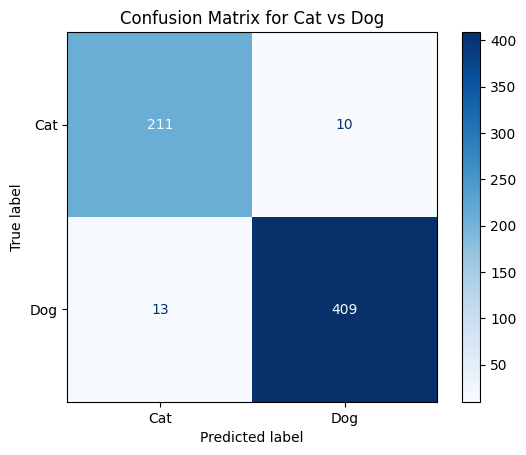

In [ ]:
_, _, _, _, (type_preds, type_labels) = evaluate(val_loader, model, criterion_breed, criterion_type)
cm = confusion_matrix(type_labels, type_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cat", "Dog"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Cat vs Dog")
plt.show()

### Графики потерь и точности

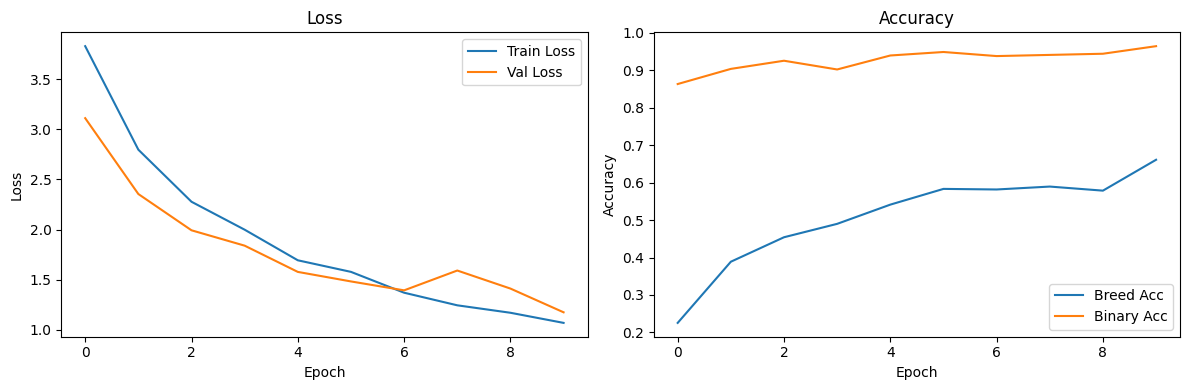

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss')

ax2.plot(breed_accs, label='Breed Acc')
ax2.plot(type_accs, label='Binary Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy')
plt.tight_layout()
plt.show()

### Генерация изображений с помощью DCGAN

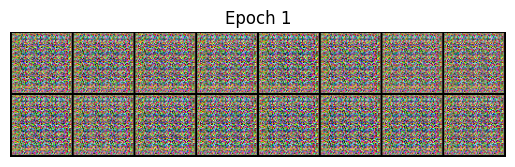

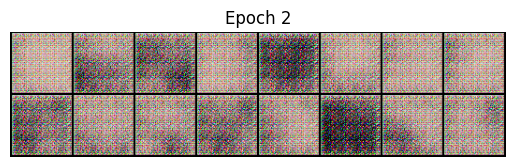

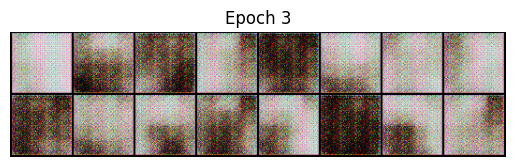

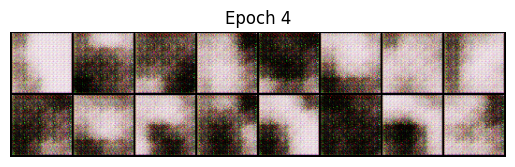

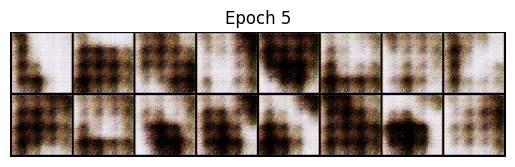

In [ ]:
# Используем тот же датасет, но уменьшим размер до 64x64
transform_gan = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

gan_dataset = PetFacesDataset(data_dir, breed_to_idx, breed_to_type, transform=transform_gan)
gan_loader = DataLoader(gan_dataset, batch_size=128, shuffle=True, num_workers=2)

# Определим генератор и дискриминатор (как в классическом DCGAN)
class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False), nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False), nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x).view(-1, 1)

nz = 100
netG = Generator(nz).to(device)
netD = Discriminator().to(device)
criterion_gan = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5,0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5,0.999))

fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Быстрое обучение (5 эпох для демонстрации)
num_epochs = 5
for epoch in range(num_epochs):
    for i, (real_imgs, _, _) in enumerate(gan_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # Обучение D
        netD.zero_grad()
        loss_real = criterion_gan(netD(real_imgs), real_labels)
        noise = torch.randn(batch_size, nz, 1, 1, device=device)
        fake = netG(noise)
        loss_fake = criterion_gan(netD(fake.detach()), fake_labels)
        lossD = loss_real + loss_fake
        lossD.backward()
        optimizerD.step()

        # Обучение G
        netG.zero_grad()
        lossG = criterion_gan(netD(fake), real_labels)
        lossG.backward()
        optimizerG.step()

    # Показываем сгенерированные изображения
    with torch.no_grad():
        fake_imgs = netG(fixed_noise).detach().cpu()
        grid = utils.make_grid(fake_imgs[:16], normalize=True)
        plt.imshow(np.transpose(grid, (1,2,0)))
        plt.axis('off')
        plt.title(f'Epoch {epoch+1}')
        plt.show()